## **<font color="red">Linear Regression</font>**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

data = load_diabetes()

# print(data.DESCR)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score: ", r2_score(y_test, y_pred))
print("RMSE : ", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score:  0.5188113124539249
RMSE :  48.72713760953253


## **<font color="red">Ridge Regression</font>**

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

data = load_diabetes()

# print(data.DESCR)

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)
model = Ridge(alpha=0.01)  # alpha = lamda

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score: ", r2_score(y_test, y_pred))
print("RMSE : ", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score:  0.5230847087541542
RMSE :  48.510284264409194


## **<font color="red"> Custome Dataset</font>**

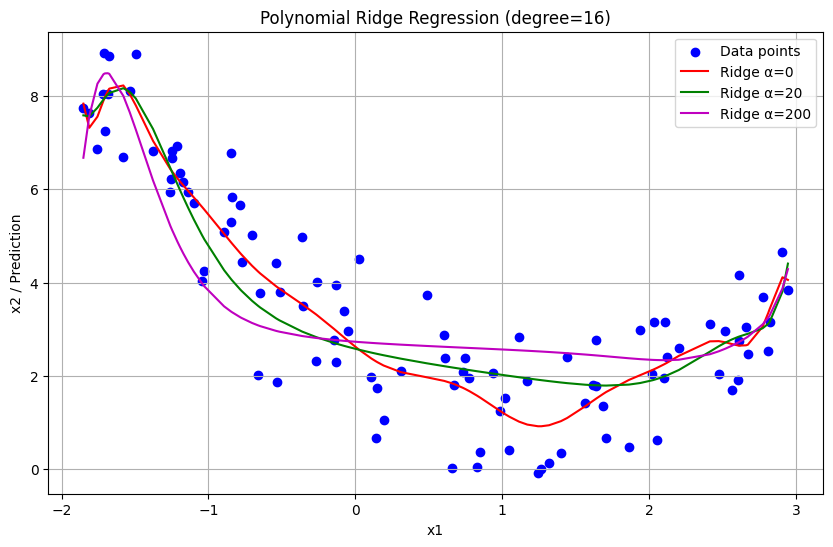

In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

# Function to train and predict Ridge model with polynomial features
def get_preds_ridge(x1, x2, alpha):
    try:
        model = Pipeline([
            ('scaler', StandardScaler()),  # Helps prevent ill-conditioned matrices
            ('poly_feats', PolynomialFeatures(degree=16, include_bias=False)),
            ('ridge', Ridge(alpha=alpha))
        ])

        model.fit(x1, x2)  # Train the model
        preds = model.predict(x1)  # Predict on same x1 for visualization
        return preds
    except Exception as e:
        print("get_preds_ridge error:", e)
        return None

# Create synthetic dataset
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

# Scatter original data
plt.figure(figsize=(10, 6))
plt.scatter(x1, x2, color='blue', label='Data points')

# Polynomial Ridge predictions for different alphas
alphas = [0, 20, 200]
colors = ['r', 'g', 'm']

# Sort x1 for smooth plot line
x1_sorted_idx = np.argsort(x1[:, 0])
x1_sorted = x1[x1_sorted_idx]

for alpha, color in zip(alphas, colors):
    preds = get_preds_ridge(x1, x2, alpha)
    if preds is not None:
        preds_sorted = preds[x1_sorted_idx]
        plt.plot(x1_sorted, preds_sorted, color=color, label=f'Ridge α={alpha}')

plt.title("Polynomial Ridge Regression (degree=16)")
plt.xlabel("x1")
plt.ylabel("x2 / Prediction")
plt.legend()
plt.grid(True)
plt.show()


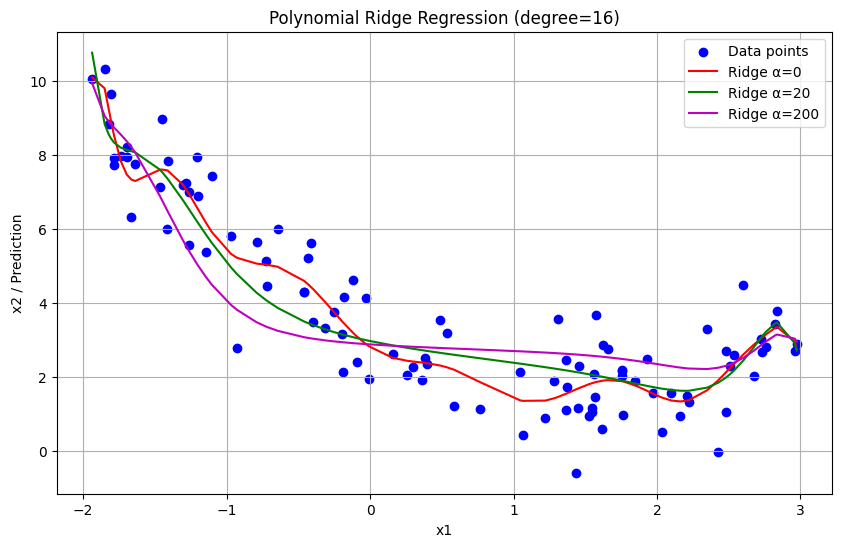

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

# Function to train and predict Ridge model with polynomial features
def get_preds_ridge(x1, x2, alpha):
    try:
        model = Pipeline([
            ('scaler', StandardScaler()),  # Helps prevent ill-conditioned matrices
            ('poly_feats', PolynomialFeatures(degree=16, include_bias=False)),
            ('ridge', Ridge(alpha=alpha))
        ])

        model.fit(x1, x2)  # Train the model
        preds = model.predict(x1)  # Predict on same x1 for visualization
        return preds
    except Exception as e:
        print("get_preds_ridge error:", e)
        return None

# Create synthetic dataset
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

# Scatter original data
plt.figure(figsize=(10, 6))
plt.scatter(x1, x2, color='blue', label='Data points')

# Polynomial Ridge predictions for different alphas
alphas = [0, 20, 200]
colors = ['r', 'g', 'm']

# Sort x1 for smooth plot line
x1_sorted_idx = np.argsort(x1[:, 0])
x1_sorted = x1[x1_sorted_idx]

for alpha, color in zip(alphas, colors):
    preds = get_preds_ridge(x1, x2, alpha)
    if preds is not None:
        preds_sorted = preds[x1_sorted_idx]
        plt.plot(x1_sorted, preds_sorted, color=color, label=f'Ridge α={alpha}')

plt.title("Polynomial Ridge Regression (degree=16)")
plt.xlabel("x1")
plt.ylabel("x2 / Prediction")
plt.legend()
plt.grid(True)
plt.show()
